<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/pytorch/PyTorch_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [183]:
# Import pytorch and subclasses
import torch
import torch.nn as nn
import torch.optim as optim
# Import numpy and pandas
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [184]:
# Data Fetcher
import kagglehub
path = kagglehub.dataset_download("jayjoshi37/fifa-player-performance-and-market-value-analytics")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fifa-player-performance-and-market-value-analytics' dataset.
Path to dataset files: /kaggle/input/fifa-player-performance-and-market-value-analytics


In [185]:
# Load Data
df = pd.read_csv(f"{path}/fifa_player_performance_market_value.csv")
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [186]:
# Feature modification
injury_map = {'No': 0, 'Yes': 1}
transfer_map = {'Low': 0, 'Medium': 1, "High": 2}

df["injury_prone"] = df["injury_prone"].replace(injury_map)
df["transfer_risk_level"] = df["transfer_risk_level"].replace(transfer_map)

df.head()

/tmp/ipython-input-666852844.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["injury_prone"] = df["injury_prone"].replace(injury_map)
/tmp/ipython-input-666852844.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["transfer_risk_level"] = df["transfer_risk_level"].replace(transfer_map)


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,0,0
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,0,2
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,0,1
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,1,1
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,0,0


In [187]:
# Data Setup
X = df[["matches_played","market_value_million_eur"]]
y = df["overall_rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [188]:
class Classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=4)
    self.layer2 = nn.ReLU()
    self.layer3 = nn.Linear(in_features=4, out_features=4)
    self.layer4 = nn.ReLU()
    self.layer5 = nn.Linear(in_features=4, out_features=1)
  def forward(self, x):
    return (self.layer5(self.layer4(self.layer3(self.layer2(self.layer1(x))))))

model = Classifier()

In [189]:
# Loss and Optimizer Functions
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01) # Corrected: Specify Adam optimizer
loss_fn = nn.MSELoss()

In [190]:
# Convert data to PyTorch tensors
X_train = torch.from_numpy(X_train.values).float()
y_train = torch.from_numpy(y_train.values).float().reshape(-1, 1)
X_test = torch.from_numpy(X_test.values).float()
y_test = torch.from_numpy(y_test.values).float().reshape(-1, 1)

In [191]:
## Training Loop
epochs = 2001

for epoch in range(epochs):

  # 1. Training Mode
  model.train()

  # 2. Forward Pass
  y_pred = model(X_train)

  # 3. Loss
  loss = loss_fn(y_pred, y_train)

  # 4. Zero gradients
  optimizer.zero_grad()

  # 5. Backpropagation
  loss.backward()

  # 6. Step the optimizer
  optimizer.step()

  # 7. Evaluation
  if epoch%20 == 0:
      model.eval()
      # 1. Forward pass
      y_test_pred = model(X_test)
      # 2. Calculate test loss
      test_loss = loss_fn(y_test_pred,y_test)
      # Print out what's happening
      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 3063.332 | Test loss: 2923.650
Epoch: 20 | Train loss: 1308.567 | Test loss: 1325.456
Epoch: 40 | Train loss: 976.734 | Test loss: 1011.862
Epoch: 60 | Train loss: 779.897 | Test loss: 813.184
Epoch: 80 | Train loss: 726.132 | Test loss: 771.047
Epoch: 100 | Train loss: 708.353 | Test loss: 752.093
Epoch: 120 | Train loss: 696.234 | Test loss: 740.685
Epoch: 140 | Train loss: 684.180 | Test loss: 727.766
Epoch: 160 | Train loss: 672.012 | Test loss: 714.758
Epoch: 180 | Train loss: 659.039 | Test loss: 700.598
Epoch: 200 | Train loss: 643.866 | Test loss: 684.272
Epoch: 220 | Train loss: 624.291 | Test loss: 662.118
Epoch: 240 | Train loss: 596.210 | Test loss: 629.742
Epoch: 260 | Train loss: 543.515 | Test loss: 565.495
Epoch: 280 | Train loss: 442.271 | Test loss: 444.861
Epoch: 300 | Train loss: 282.132 | Test loss: 272.134
Epoch: 320 | Train loss: 152.697 | Test loss: 143.652
Epoch: 340 | Train loss: 117.455 | Test loss: 111.117
Epoch: 360 | Train loss: 107.

In [192]:
# Final Performance
model.eval()
with torch.inference_mode():
    predictions = model(X_train)
    predictions_test = model(X_test)

Final Test Mean Squared Error (MSE): 93.546
R-squared (R2) Score on Test Set: -0.000


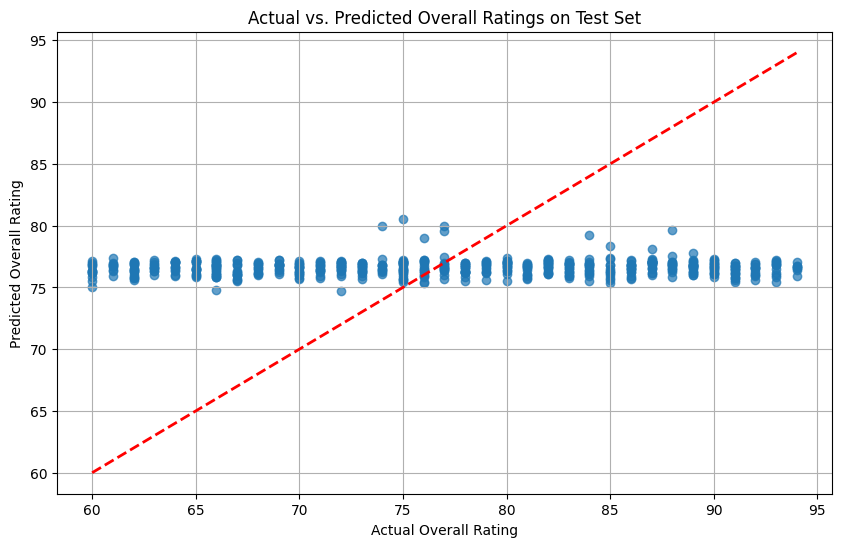

In [193]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Convert predictions and actual values to numpy for plotting and sklearn metrics
predictions_test_np = predictions_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate final Test MSE (which is your loss function)
final_test_mse = loss_fn(predictions_test, y_test).item()
print(f"Final Test Mean Squared Error (MSE): {final_test_mse:.3f}")

# Calculate R-squared score
r2 = r2_score(y_test_np, predictions_test_np)
print(f"R-squared (R2) Score on Test Set: {r2:.3f}")

# Visualization: Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_np, predictions_test_np, alpha=0.7)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2) # y=x line
plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Actual vs. Predicted Overall Ratings on Test Set")
plt.grid(True)
plt.show()